# Day 14 - E-commerce Sales Analysis

## Project Overview

This project analyzes an e-commerce sales dataset using Pandas, NumPy, SQL concepts, and visualization.

### Workflow

1. Load the dataset
2. Inspect the data
3. Clean the data
4. Create the Sales column
5. Analyze sales
6. Analyze products and categories
7. Analyze daily and monthly sales
8. Visualize the results
9. Calculate correlation
10. Write business insights

## Dataset Columns

- OrderID - Unique order number
- Date - Order date
- Product - Product purchased
- Category - Product category
- Quantity - Number of items sold
- Price - Price per item
- Sales - Quantity × Price

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ecommerce_sales.csv")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,OrderID,Date,Product,Category,Quantity,Price
0,1001,2026-01-02,Laptop,Electronics,2,50000
1,1002,2026-01-03,Mouse,Accessories,5,800
2,1003,2026-01-05,Keyboard,Accessories,3,1500
3,1004,2026-01-07,Laptop,Electronics,1,50000
4,1005,2026-01-10,Headphones,Audio,4,2500


In [2]:
print("First 5 rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nBasic Statistics:")
display(df.describe())

First 5 rows:


,OrderID,Date,Product,Category,Quantity,Price
0,1001,2026-01-02,Laptop,Electronics,2,50000
1,1002,2026-01-03,Mouse,Accessories,5,800
2,1003,2026-01-05,Keyboard,Accessories,3,1500
3,1004,2026-01-07,Laptop,Electronics,1,50000
4,1005,2026-01-10,Headphones,Audio,4,2500



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   OrderID   16 non-null     int64
 1   Date      16 non-null     str  
 2   Product   16 non-null     str  
 3   Category  16 non-null     str  
 4   Quantity  16 non-null     int64
 5   Price     16 non-null     int64
dtypes: int64(3), str(3)
memory usage: 900.0 bytes

Missing Values:
OrderID     0
Date        0
Product     0
Category    0
Quantity    0
Price       0
dtype: int64

Duplicate Rows:
1

Basic Statistics:


,OrderID,Quantity,Price
count,16.000000,16.000000,16.000000
mean,1007.625000,3.625000,15950.000000
std,4.573474,2.418677,20260.997014
min,1001.000000,1.000000,800.000000
25%,1003.750000,2.000000,1325.000000
50%,1007.500000,3.000000,2500.000000
75%,1011.250000,5.000000,30000.000000
max,1015.000000,10.000000,50000.000000


In [3]:
print("Duplicate rows before cleaning:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows before cleaning: 1
Duplicate rows after cleaning: 0


In [4]:
df["Sales"] = df["Quantity"] * df["Price"]

print("Sales column created:")
display(df.head())

Sales column created:


,OrderID,Date,Product,Category,Quantity,Price,Sales
0,1001,2026-01-02,Laptop,Electronics,2,50000,100000
1,1002,2026-01-03,Mouse,Accessories,5,800,4000
2,1003,2026-01-05,Keyboard,Accessories,3,1500,4500
3,1004,2026-01-07,Laptop,Electronics,1,50000,50000
4,1005,2026-01-10,Headphones,Audio,4,2500,10000


In [5]:
total_sales = df["Sales"].sum()
average_sales = df["Sales"].mean()
highest_sales = df["Sales"].max()
lowest_sales = df["Sales"].min()

print("Total Sales:", total_sales)
print("Average Sales:", average_sales)
print("Highest Sales:", highest_sales)
print("Lowest Sales:", lowest_sales)

Total Sales: 438100
Average Sales: 29206.666666666668
Highest Sales: 100000
Lowest Sales: 4000


In [6]:
product_sales = (
    df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Product:")
display(product_sales)

Sales by Product:


Product
Laptop        200000
Phone         180000
Headphones     22500
Keyboard       18000
Mouse          17600
Name: Sales, dtype: int64

In [7]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Category:")
display(category_sales)

Sales by Category:


Category
Electronics    380000
Accessories     35600
Audio           22500
Name: Sales, dtype: int64

In [8]:
quantity_by_product = (
    df.groupby("Product")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print("Quantity Sold by Product:")
display(quantity_by_product)

Quantity Sold by Product:


Product
Mouse         22
Keyboard      12
Headphones     9
Phone          6
Laptop         4
Name: Quantity, dtype: int64

In [9]:
daily_sales = (
    df.groupby("Date")["Sales"]
    .sum()
    .sort_index()
)

print("Daily Sales:")
display(daily_sales)

Daily Sales:


Date
2026-01-02    100000
2026-01-03      4000
2026-01-05      4500
2026-01-07     50000
2026-01-10     10000
2026-01-12     60000
2026-01-15      8000
2026-01-18      7500
2026-01-20      7500
2026-01-22     30000
2026-02-02     50000
2026-02-05     90000
2026-02-08      5600
2026-02-12      5000
2026-02-15      6000
Name: Sales, dtype: int64

In [10]:
df["Date"] = pd.to_datetime(df["Date"])

In [11]:
monthly_sales = (
    df.groupby(df["Date"].dt.month)["Sales"]
    .sum()
)

print("Monthly Sales:")
display(monthly_sales)

Monthly Sales:


Date
1    281500
2    156600
Name: Sales, dtype: int64

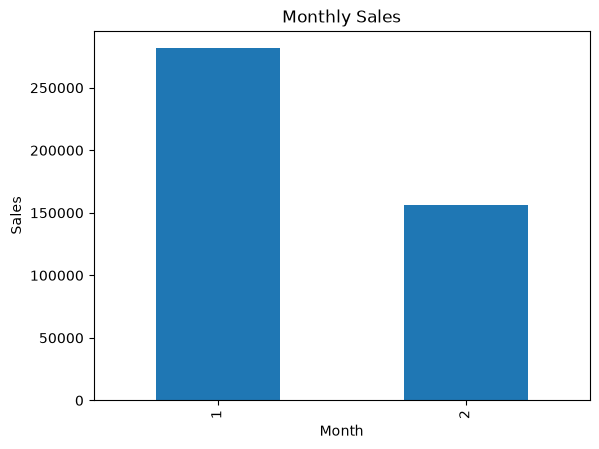

In [12]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind="bar")

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Sales")

plt.show()

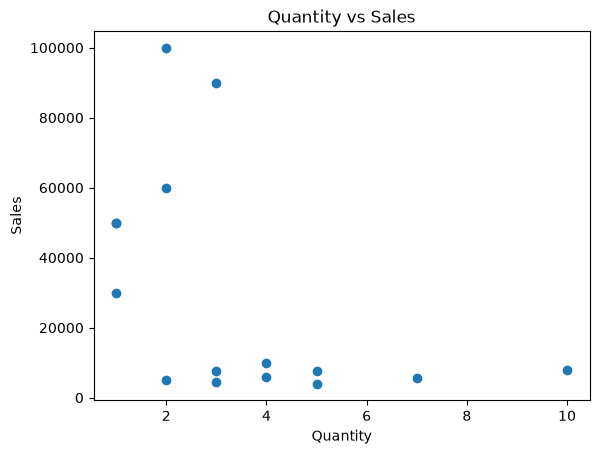

In [13]:
plt.scatter(df["Quantity"], df["Sales"])

plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.title("Quantity vs Sales")

plt.show()

In [14]:
correlation = df[["Quantity", "Price", "Sales"]].corr()

print("Correlation:")
display(correlation)

Correlation:


,Quantity,Price,Sales
Quantity,1.000000,-0.647176,-0.473986
Price,-0.647176,1.000000,0.850676
Sales,-0.473986,0.850676,1.000000


## Business Insights

1. The best-selling product generated the highest total revenue.
2. The highest-revenue category contributed the most to overall sales.
3. The product with the highest quantity sold may not be the product with the highest revenue.
4. Monthly sales can be compared to identify stronger and weaker sales periods.
5. The correlation between Quantity and Sales helps us understand their relationship.

## Conclusion

This project demonstrated a complete data analysis workflow using Pandas, NumPy concepts, and visualization.

The workflow included:

- Loading e-commerce data
- Inspecting the dataset
- Removing duplicate records
- Creating the Sales column
- Performing sales analysis
- Analyzing products and categories
- Analyzing daily and monthly sales
- Creating visualizations
- Studying correlation
- Extracting business insights

This project helped demonstrate how raw data can be transformed into meaningful information for decision-making.